# Signal Engine — Intraday Forecasting with Risk Management

**How to use:**
1. Edit **Cell 2 (CONFIG)** only — set your asset, timeframe, and account size.
2. Run all cells top-to-bottom (`Kernel → Restart & Run All`).
3. The signal cell prints entry / TP / SL and position size.
4. Optionally enable the live scanner (last cell) for continuous updates.

**Prediction engine:** AutoTheta + AutoETS ensemble (statsforecast).  
**Risk management:** ATR-based SL, fixed-fractional position sizing, R:R filter.  
**Extra filters:** ADX trend strength, RSI regime, multi-TF bias alignment.

In [215]:
import sys, os, warnings, threading, time
warnings.filterwarnings('ignore')
ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone

from statsforecast import StatsForecast
from statsforecast.models import AutoTheta, AutoETS

# ── Use MT5 for real-time data (no yfinance delay) ────────────────────────
from src.mt5_feed import fetch_multi_timeframe, initialize as mt5_init
mt5_init()

from src.feature_engineering import compute_features, build_multi_tf_snapshot, atr as calc_atr, rsi as calc_rsi
from src.signal_engine       import _score_timeframe
from src.signal_logger       import SignalLogger

plt.rcParams.update({
    'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False
})

print('Imports OK')
print('Data source: MT5 (real-time)')
print('Supported assets: XAUUSD, XAGUSD, EURUSD, GBPUSD, USDJPY, USDCHF, AUDUSD, USDCAD, NZDUSD, GBPJPY, EURJPY, EURGBP')

Imports OK
Data source: MT5 (real-time)
Supported assets: XAUUSD, XAGUSD, EURUSD, GBPUSD, USDJPY, USDCHF, AUDUSD, USDCAD, NZDUSD, GBPJPY, EURJPY, EURGBP


In [216]:
# ── Load Chronos zero-shot model (cached after first load) ───────────────
# Benchmark Sharpe (H=1): AutoTheta=0.771, Chronos=0.498, AutoETS=0.162
# Weights are normalised so they sum to 1.0.
_SHARPE = {'AutoTheta': 0.771, 'AutoETS': 0.162, 'Chronos': 0.498}
_W_SUM  = sum(_SHARPE.values())
MODEL_WEIGHTS = {k: v / _W_SUM for k, v in _SHARPE.items()}

_chronos_forecaster = None   # lazy-loaded below

def _load_chronos():
    global _chronos_forecaster
    if _chronos_forecaster is not None:
        return _chronos_forecaster
    try:
        from src.new_models import ChronosZeroShotForecaster
        print('Loading Chronos-bolt-tiny ...', end=' ', flush=True)
        _chronos_forecaster = ChronosZeroShotForecaster('amazon/chronos-bolt-tiny')
        print('OK')
    except Exception as e:
        print(f'Chronos load failed ({e}) — will use AutoTheta+AutoETS only')
        _chronos_forecaster = None
    return _chronos_forecaster

print(f'Model weights  : AutoTheta={MODEL_WEIGHTS["AutoTheta"]:.3f}  '
      f'AutoETS={MODEL_WEIGHTS["AutoETS"]:.3f}  Chronos={MODEL_WEIGHTS["Chronos"]:.3f}')
print('Chronos        : will load on first forecast call')

Model weights  : AutoTheta=0.539  AutoETS=0.113  Chronos=0.348
Chronos        : will load on first forecast call


In [217]:
# ╔══════════════════════════════════════════════════════════════╗
# ║              EDIT ONLY THIS CELL                           ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Asset & Timeframe ──────────────────────────────────────────
ASSET    = 'XAUUSD'   # XAUUSD | EURUSD | GBPUSD | USDJPY | USDCAD | GBPJPY
ENTRY_TF = '15min'    # 1min | 5min | 15min | 30min | 1H | 4H | 1D

# ── Prediction ─────────────────────────────────────────────────
TRAIN_BARS  = 200     # bars of history fed to each model
FORECAST_H  = 3       # how many bars ahead to predict

# ── Model ensemble (toggle Chronos — adds ~3s on first call) ───
USE_CHRONOS = True

# ── Risk Management ────────────────────────────────────────────
ACCOUNT_BALANCE = 1000.0
MAX_RISK_PCT    = 0.1
RR_RATIO        = 2.0
ATR_SL_MULT     = 1.2
MIN_RR          = 1.5

# ── Filters ────────────────────────────────────────────────────
CONFIDENCE_THRESHOLD = 55
ADX_TREND_THRESHOLD  = 22 # ADX above 22 which we consider the market to be trending (no mean reversion signals)
RSI_OVERBOUGHT       = 75 # RSI above this level is considered overbought (potential sell signal)
RSI_OVERSOLD         = 25 # RSI below this level is considered oversold (potential buy signal)

# ── TF stack for multi-timeframe bias ──────────────────────────
_TF_STACKS = {
    '1min':  ['1min',  '5min',  '15min', '30min', '1H', '4H', '1D'],
    '5min':  ['5min',  '15min', '1H',    '4H', '1D'],
    '15min': ['15min', '1H',    '4H', '1D'],
    '30min': ['30min', '1H',    '4H', '1D'],
    '1H':    ['1H',    '4H',    '1D'],
    '4H':    ['4H',    '1D'],
    '1D':    ['1D'],
}
TIMEFRAMES = _TF_STACKS.get(ENTRY_TF, [ENTRY_TF])

print(f'Asset      : {ASSET}')
print(f'Entry TF   : {ENTRY_TF}  |  TF stack: {TIMEFRAMES}')
print(f'Train bars : {TRAIN_BARS}  |  Forecast: {FORECAST_H} bars ahead')
print(f'Chronos    : {"ON" if USE_CHRONOS else "OFF"}')
print(f'Account    : ${ACCOUNT_BALANCE:,.0f}  |  Risk/trade: {MAX_RISK_PCT:.1%}')
print(f'R:R target : 1:{RR_RATIO}  |  ATR SL mult: {ATR_SL_MULT}x  |  Min R:R: {MIN_RR}')
print(f'Filters    : Conf>={CONFIDENCE_THRESHOLD}%  ADX>={ADX_TREND_THRESHOLD}  RSI OB={RSI_OVERBOUGHT} OS={RSI_OVERSOLD}')

Asset      : XAUUSD
Entry TF   : 15min  |  TF stack: ['15min', '1H', '4H', '1D']
Train bars : 200  |  Forecast: 3 bars ahead
Chronos    : ON
Account    : $1,000  |  Risk/trade: 10.0%
R:R target : 1:2.0  |  ATR SL mult: 1.2x  |  Min R:R: 1.5
Filters    : Conf>=55%  ADX>=22  RSI OB=75 OS=25


In [218]:
import requests
from datetime import datetime, timezone

def get_news_events():
    try:
        url = (
            "https://nfs.faireconomy.media/"
            "ff_calendar_thisweek.json"
        )
        response = requests.get(url, timeout=10)
        events = response.json()
        now = datetime.now(timezone.utc)
        upcoming = []
        for event in events:
            if event.get('impact') != 'High':
                continue
            try:
                event_time = datetime.fromisoformat(
                    event['date'].replace('Z', '+00:00')
                )
                diff_minutes = (
                    event_time - now
                ).total_seconds() / 60
                if -30 <= diff_minutes <= 60:
                    upcoming.append({
                        'title':   event.get('title', ''),
                        'country': event.get('country', ''),
                        'minutes': diff_minutes
                    })
            except:
                continue
        return upcoming
    except:
        return []

def is_news_zone():
    events = get_news_events()
    gold_relevant = ['USD', 'XAU', 'US']
    for event in events:
        if event['country'] in gold_relevant:
            return True, event
    return False, None

def get_fear_greed():
    try:
        url = (
            "https://production.dataviz.cnn.io/"
            "index/fearandgreed/graphdata"
        )
        headers = {'User-Agent': 'Mozilla/5.0'}
        r = requests.get(
            url, headers=headers, timeout=10
        )
        data = r.json()
        score  = float(
            data['fear_and_greed']['score']
        )
        rating = data['fear_and_greed']['rating']
        return score, rating
    except:
        return 50, 'neutral'

def get_sentiment_bias(direction):
    score, rating = get_fear_greed()
    if direction == 'BUY':
        if score < 40:
            return f'😨 Fear ({score:.0f}) confirms BUY'
        elif score > 60:
            return f'😎 Greed ({score:.0f}) caution BUY'
        else:
            return f'😐 Neutral ({score:.0f})'
    else:
        if score > 60:
            return f'😎 Greed ({score:.0f}) confirms SELL'
        elif score < 40:
            return f'😨 Fear ({score:.0f}) caution SELL'
        else:
            return f'😐 Neutral ({score:.0f})'

print("Functions defined ✓")

Functions defined ✓


In [219]:
print(f'Fetching {ASSET} data ...')
tf_data = fetch_multi_timeframe(ASSET, TIMEFRAMES, bars=500)

for tf, df in tf_data.items():
    atr14 = calc_atr(df, 14).iloc[-1]
    print(f'  {tf:6s}: {len(df):4d} bars | last={df["close"].iloc[-1]:.3f} | ATR(14)={atr14:.3f} | {df.index[-1]}')

entry_df  = tf_data[ENTRY_TF]
cur_price = float(entry_df['close'].iloc[-1])
cur_atr   = float(calc_atr(entry_df, 14).iloc[-1])
cur_time  = entry_df.index[-1]

print(f'\nCurrent price : {cur_price:.5f}')
print(f'Current ATR14 : {cur_atr:.5f}')
print(f'Last bar time : {cur_time}')

Fetching XAUUSD data ...
  15min :  500 bars | last=4533.500 | ATR(14)=7.577 | 2026-06-02 13:15:00+02:00
  1H    :  500 bars | last=4533.500 | ATR(14)=16.874 | 2026-06-02 13:00:00+02:00
  4H    :  500 bars | last=4533.500 | ATR(14)=36.656 | 2026-06-02 10:00:00+02:00
  1D    :  500 bars | last=4533.500 | ATR(14)=106.105 | 2026-06-02 02:00:00+02:00

Current price : 4533.50000
Current ATR14 : 7.57720
Last bar time : 2026-06-02 13:15:00+02:00


In [220]:
# ── 3-model ensemble: AutoTheta + AutoETS + Chronos ──────────────────────
# Weights derived from walk-forward Sharpe in the benchmark (H=1).

def _season_len(tf):
    return {'1min': 390, '5min': 78, '15min': 26, '30min': 13,
            '1H': 7, '4H': 2, '1D': 5}.get(tf, 10)


def _run_statsforecast(df, tf, train_bars, h):
    """Returns (theta_ret[h], ets_ret[h]) as 1-D arrays of log-return forecasts."""
    close   = df['close'].dropna()
    log_ret = np.log(close / close.shift(1)).dropna()
    series  = log_ret.iloc[-train_bars:].values.astype(float)
    n, sl   = len(series), _season_len(tf)
    sf_df = pd.DataFrame({
        'unique_id': ['asset'] * n,
        'ds': pd.date_range('2000-01-01', periods=n, freq='15min'),
        'y': series,
    })
    preds = StatsForecast(
        models=[AutoTheta(season_length=sl), AutoETS(season_length=sl)],
        freq='15min', n_jobs=1
    ).forecast(df=sf_df, h=h)
    return preds['AutoTheta'].values, preds['AutoETS'].values


def _run_chronos(df, train_bars, h):
    """Returns predicted return for bar +h (raw price context, zero-shot)."""
    forecaster = _load_chronos()
    if forecaster is None:
        return None
    close   = df['close'].dropna()
    context = close.iloc[-train_bars:].values.astype(float)
    pred_path = forecaster.predict_close_path(context, prediction_length=h)
    last_px   = float(close.iloc[-1])
    # Convert predicted price at horizon h to cumulative log-return
    pred_log_ret = np.log(pred_path / last_px)     # shape (h,)
    return pred_log_ret                             # array of log-rets per bar


def run_ensemble_forecast(df, tf, train_bars, h, use_chronos=True):
    close    = df['close'].dropna()
    last_px  = float(close.iloc[-1])

    theta, ets = _run_statsforecast(df, tf, train_bars, h)

    # Chronos works on cumulative log-returns; convert theta/ets to same space
    theta_cum = np.cumsum(theta)
    ets_cum   = np.cumsum(ets)

    w_theta = MODEL_WEIGHTS['AutoTheta']
    w_ets   = MODEL_WEIGHTS['AutoETS']
    w_chron = MODEL_WEIGHTS['Chronos']

    chronos_cum = None
    if use_chronos:
        chronos_log = _run_chronos(df, train_bars, h)
        if chronos_log is not None:
            chronos_cum = chronos_log   # already cumulative from predict_close_path

    if chronos_cum is not None:
        # Re-normalise weights to only active models
        w_sum   = w_theta + w_ets + w_chron
        ens_cum = (w_theta * theta_cum + w_ets * ets_cum + w_chron * chronos_cum) / w_sum
    else:
        w_sum   = w_theta + w_ets
        ens_cum = (w_theta * theta_cum + w_ets * ets_cum) / w_sum

    pred_prices = [last_px * np.exp(ens_cum[i]) for i in range(h)]

    # Bar-1 return drives the direction signal
    pred_ret = float(ens_cum[0])

    return {
        'theta':        theta,
        'ets':          ets,
        'chronos_cum':  chronos_cum,
        'ensemble_cum': ens_cum,
        'pred_prices':  pred_prices,
        'direction':    int(np.sign(pred_ret)),
        'pred_return':  pred_ret,
        'chronos_used': chronos_cum is not None,
    }


# ── Run ───────────────────────────────────────────────────────────────────
print('Running ensemble forecast ...')
fc = run_ensemble_forecast(entry_df, ENTRY_TF, TRAIN_BARS, FORECAST_H, use_chronos=USE_CHRONOS)

dir_label = 'BUY' if fc['direction'] > 0 else ('SELL' if fc['direction'] < 0 else 'NEUTRAL')
models_used = ['AutoTheta', 'AutoETS'] + (['Chronos'] if fc['chronos_used'] else [])
print(f'Models used : {", ".join(models_used)}')
print(f'\nEnsemble forecast ({ENTRY_TF}, {FORECAST_H} bars ahead):')
print(f'  Direction   : {dir_label}')
print(f'  Pred return : {fc["pred_return"]:+.5f}  ({fc["pred_return"]*100:+.3f}%)')
print(f'  Pred prices : {", ".join([f"{p:.3f}" for p in fc["pred_prices"]])}')
print()
hdr = f'  {"Bar":5s}  {"AutoTheta":>12s}  {"AutoETS":>12s}'
if fc['chronos_used']:
    hdr += f'  {"Chronos":>12s}'
hdr += f'  {"Ensemble":>12s}'
print(hdr)
for i in range(FORECAST_H):
    row = f'  Bar+{i+1}  {fc["theta"][i]:>+12.5f}  {fc["ets"][i]:>+12.5f}'
    if fc['chronos_used']:
        # Show per-bar log-ret (diff of cumsum for i>0)
        c_bar = fc['chronos_cum'][i] - (fc['chronos_cum'][i-1] if i > 0 else 0)
        row += f'  {c_bar:>+12.5f}'
    row += f'  {fc["ensemble_cum"][i]:>+12.5f}'
    print(row)

Running ensemble forecast ...


Loading Chronos-bolt-tiny ... OK
Models used : AutoTheta, AutoETS, Chronos

Ensemble forecast (15min, 3 bars ahead):
  Direction   : BUY
  Pred return : +0.00011  (+0.011%)
  Pred prices : 4533.983, 4534.897, 4535.746

  Bar       AutoTheta       AutoETS       Chronos      Ensemble
  Bar+1      +0.00026      +0.00003      -0.00010      +0.00011
  Bar+2      +0.00026      +0.00003      +0.00017      +0.00031
  Bar+3      +0.00026      +0.00003      +0.00013      +0.00050


In [221]:
# ── Market context: multi-TF bias + all indicators ────────────────────────

snapshots = build_multi_tf_snapshot(tf_data)
scores    = {tf: _score_timeframe(snap) for tf, snap in snapshots.items()}
buy_tfs   = [tf for tf, sc in scores.items() if sc['direction'] ==  1]
sell_tfs  = [tf for tf, sc in scores.items() if sc['direction'] == -1]

print('Multi-timeframe bias:')
print(f'  {"TF":6s}  {"Direction":10s}  {"Strength":8s}  Factors')
print('  ' + '-'*70)
for tf, sc in scores.items():
    d = {1: 'BULLISH', -1: 'BEARISH', 0: 'NEUTRAL'}[sc['direction']]
    print(f'  {tf:6s}  {d:10s}  {sc["strength"]:.3f}     {", ".join(sc["factors"][:5])}')

# ── All indicators via compute_features (single source of truth) ──────────
feat     = compute_features(entry_df)
rsi_v    = float(feat['rsi_14'].iloc[-1])   if 'rsi_14'    in feat.columns else 50.0
adx_v    = float(feat['adx_14'].iloc[-1])   if 'adx_14'    in feat.columns else 0.0
plus_di  = float(feat['plus_di'].iloc[-1])  if 'plus_di'   in feat.columns else 0.0
minus_di = float(feat['minus_di'].iloc[-1]) if 'minus_di'  in feat.columns else 0.0
ema20    = float(feat['ema_20'].iloc[-1])   if 'ema_20'    in feat.columns else cur_price
ema50    = float(feat['ema_50'].iloc[-1])   if 'ema_50'    in feat.columns else cur_price
macd_h   = float(feat['macd_hist'].iloc[-1])if 'macd_hist' in feat.columns else 0.0
stoch_k  = float(feat['stoch_k'].iloc[-1])  if 'stoch_k'   in feat.columns else 50.0
bb_pct   = float(feat['bb_pct'].iloc[-1])   if 'bb_pct'    in feat.columns else 0.5

# Volatility regime: current ATR vs 20-bar ATR average
atr_ma     = calc_atr(entry_df, 14).rolling(20).mean().iloc[-1]
vol_regime = 'HIGH' if cur_atr > atr_ma * 1.2 else ('LOW' if cur_atr < atr_ma * 0.8 else 'NORMAL')

print(f'\nEntry-TF indicators ({ENTRY_TF}):')
print(f'  RSI(14)    : {rsi_v:.1f}  {"[OVERBOUGHT]" if rsi_v > RSI_OVERBOUGHT else "[OVERSOLD]" if rsi_v < RSI_OVERSOLD else ""}')
print(f'  Stoch %K   : {stoch_k:.1f}')
print(f'  ADX(14)    : {adx_v:.1f}  +DI={plus_di:.1f}  -DI={minus_di:.1f}  {"[TRENDING]" if adx_v >= ADX_TREND_THRESHOLD else "[RANGING]"}') 
print(f'  MACD hist  : {macd_h:+.5f}  {"BULLISH" if macd_h > 0 else "BEARISH"}')
print(f'  EMA20/50   : {ema20:.3f} / {ema50:.3f}  Price {"ABOVE" if cur_price > ema20 else "BELOW"} EMA20')
print(f'  BB %B      : {bb_pct:.2f}  (0=lower band, 0.5=mid, 1=upper band)')
print(f'  ATR regime : {vol_regime}  (cur={cur_atr:.4f}  avg={atr_ma:.4f})')

Multi-timeframe bias:
  TF      Direction   Strength  Factors
  ----------------------------------------------------------------------
  15min   BULLISH     1.000     price>ema20, ema20>ema50, ema50>ema200, rsi_bull(66), macd_bull
  1H      BULLISH     0.568     price>ema20, ema20>ema50, ema50<ema200, rsi_bull(64), macd_bull
  4H      NEUTRAL     0.107     price>ema20, ema20<ema50, ema50<ema200, rsi_neutral(56), macd_bull
  1D      NEUTRAL     0.057     price<ema20, ema20<ema50, ema50>ema200, rsi_neutral(46), macd_bull

Entry-TF indicators (15min):
  RSI(14)    : 66.5  
  Stoch %K   : 69.6
  ADX(14)    : 32.7  +DI=28.7  -DI=15.0  [TRENDING]
  MACD hist  : +0.05152  BULLISH
  EMA20/50   : 4522.282 / 4507.467  Price ABOVE EMA20
  BB %B      : 0.71  (0=lower band, 0.5=mid, 1=upper band)
  ATR regime : NORMAL  (cur=7.5772  avg=8.3116)


In [222]:
# ── Signal: combine model + filters → entry / TP / SL ────────────────────

def compute_signal():
    model_dir = fc['direction']   # +1 BUY / -1 SELL / 0 neutral
    if model_dir == 0:
        return None, 'Model is NEUTRAL'

    signal = 'BUY' if model_dir > 0 else 'SELL'

    # RSI extreme filter
    if signal == 'BUY'  and rsi_v > RSI_OVERBOUGHT:
        return None, f'RSI={rsi_v:.0f} overbought — skip BUY'
    if signal == 'SELL' and rsi_v < RSI_OVERSOLD:
        return None, f'RSI={rsi_v:.0f} oversold — skip SELL'

    aligned_tfs  = buy_tfs  if signal == 'BUY' else sell_tfs
    opposite_tfs = sell_tfs if signal == 'BUY' else buy_tfs
    total_tfs    = len(scores)
    align_pct    = len(aligned_tfs) / total_tfs * 100 if total_tfs > 0 else 0

    # ── Confidence score (0-95) ───────────────────────────────────────────
    conf = 0
    conf += min(35, int(align_pct * 0.5))                          # TF alignment
    conf += 20 if adx_v >= ADX_TREND_THRESHOLD else 5             # ADX trending
    conf += 15 if abs(fc['pred_return']) > 0.0003 else 8          # model magnitude
    conf += 15 if ((macd_h > 0) == (signal == 'BUY')) else 0      # MACD agrees
    conf += 10 if ((cur_price > ema20) == (signal == 'BUY')) else 0  # price vs EMA20
    conf += 5  if len(opposite_tfs) == 0 else 0                    # no opposing TFs
    conf  = min(conf, 95)

    if conf < CONFIDENCE_THRESHOLD:
        return None, f'Confidence={conf}% < threshold {CONFIDENCE_THRESHOLD}%'

    # ── Entry / SL / TP ───────────────────────────────────────────────────
    entry   = cur_price
    sl_dist = cur_atr * ATR_SL_MULT
    tp_dist = sl_dist * RR_RATIO

    sl = entry - sl_dist if signal == 'BUY' else entry + sl_dist
    tp = entry + tp_dist if signal == 'BUY' else entry - tp_dist

    tp_ladder = [p for p in fc['pred_prices']
                 if (p > entry if signal == 'BUY' else p < entry)]

    if tp_dist / sl_dist < MIN_RR:
        return None, f'R:R={tp_dist/sl_dist:.2f} < minimum {MIN_RR}'

    return {
        'signal': signal, 'entry': entry, 'sl': sl, 'tp': tp,
        'tp_ladder': tp_ladder, 'sl_dist': sl_dist, 'tp_dist': tp_dist,
        'rr': tp_dist / sl_dist, 'confidence': conf,
        'adx': adx_v, 'rsi': rsi_v, 'vol_regime': vol_regime,
        'aligned_tfs': aligned_tfs, 'pred_return': fc['pred_return'],
    }, None

sig, reason = compute_signal()

print('=' * 55)
if sig:
    arrow = '^' if sig['signal'] == 'BUY' else 'v'
    print(f'  SIGNAL  : {sig["signal"]} {arrow}  {ASSET}  [{ENTRY_TF}]')
    print(f'  Time    : {datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")}')
    print(f'  Conf    : {sig["confidence"]}%')
    print('-' * 55)
    print(f'  Entry      : {sig["entry"]:.5f}')
    print(f'  Stop Loss  : {sig["sl"]:.5f}  ({sig["sl_dist"]:.5f} pts  = {ATR_SL_MULT}x ATR)')
    print(f'  Take Profit: {sig["tp"]:.5f}  ({sig["tp_dist"]:.5f} pts)')
    print(f'  R:R        : 1:{sig["rr"]:.2f}')
    if sig['tp_ladder']:
        print(f'  TP ladder  : {", ".join([f"{p:.3f}" for p in sig["tp_ladder"]])}')
    print('-' * 55)
    print(f'  ADX(14)   : {sig["adx"]:.1f}  |  RSI(14): {sig["rsi"]:.1f}')
    print(f'  Vol regime: {sig["vol_regime"]}  |  Model pred: {sig["pred_return"]:+.4f}')
    print(f'  Aligned TFs: {sig["aligned_tfs"]}')
else:
    print(f'  NO SIGNAL')
    print(f'  Reason  : {reason}')
print('=' * 55)

  SIGNAL  : BUY ^  XAUUSD  in]
  Time    : 2026-06-02 08:26 UTC
  Conf    : 83%
-------------------------------------------------------
  Entry      : 4533.50000
  Stop Loss  : 4524.40736  (9.09264 pts  = 1.2x ATR)
  Take Profit: 4551.68528  (18.18528 pts)
  R:R        : 1:2.00
  TP ladder  : 4533.983, 4534.897, 4535.746
-------------------------------------------------------
  ADX(14)   : 32.7  |  RSI(14): 66.5
  Vol regime: NORMAL  |  Model pred: +0.0001
  Aligned TFs: ['15min', '1H']


In [223]:
# ── Position sizing & full trade plan ────────────────────────────────────

if sig is None:
    print('No signal — skip position sizing.')
else:
    risk_usd = ACCOUNT_BALANCE * MAX_RISK_PCT

    # Volatility scaling: reduce 25% in high-vol
    vol_scale  = 0.75 if sig['vol_regime'] == 'HIGH' else 1.0

    # Confidence scaling
    if   sig['confidence'] >= 75: conf_scale = 1.00
    elif sig['confidence'] >= 60: conf_scale = 0.75
    else:                         conf_scale = 0.50

    adj_risk  = risk_usd * vol_scale * conf_scale
    sl_points = abs(sig['entry'] - sig['sl'])
    is_gold   = ASSET in ('XAUUSD', 'XAGUSD')

    if is_gold:
        position_units = adj_risk / sl_points
        unit_label     = 'oz'
        reward_usd     = position_units * abs(sig['tp'] - sig['entry'])
    else:
        pip_size      = 0.0001 if 'JPY' not in ASSET else 0.01
        sl_pips       = sl_points / pip_size
        position_units = round(adj_risk / (sl_pips * 10.0), 2)
        unit_label    = 'lots'
        reward_usd    = position_units * (abs(sig['tp'] - sig['entry']) / pip_size) * 10.0

    print('RISK MANAGEMENT')
    print('=' * 55)
    print(f'  Account balance  : ${ACCOUNT_BALANCE:,.2f}')
    print(f'  Base risk        : ${risk_usd:.2f}  ({MAX_RISK_PCT:.1%})')
    print(f'  Volatility scale : {vol_scale:.0%}  ({sig["vol_regime"]} vol)')
    print(f'  Confidence scale : {conf_scale:.0%}  ({sig["confidence"]}% conf)')
    print(f'  Adjusted risk    : ${adj_risk:.2f}')
    print('-' * 55)
    print(f'  SL distance      : {sl_points:.5f}')
    print(f'  Position size    : {position_units:.4f} {unit_label}')
    print(f'  Max loss (SL hit): ${adj_risk:.2f}  ({adj_risk/ACCOUNT_BALANCE:.2%} of account)')
    print(f'  Max gain (TP hit): ${reward_usd:.2f}  ({reward_usd/ACCOUNT_BALANCE:.2%} of account)')
    print(f'  R:R              : 1:{reward_usd/adj_risk:.2f}')
    print('=' * 55)
    print()
    print('TRADE PLAN')
    print(f'  {sig["signal"]} {ASSET} @ {sig["entry"]:.5f}')
    print(f'  Size : {position_units:.4f} {unit_label}')
    print(f'  SL   : {sig["sl"]:.5f}  (risk ${adj_risk:.2f})')
    print(f'  TP   : {sig["tp"]:.5f}  (reward ${reward_usd:.2f})')

RISK MANAGEMENT
  Account balance  : $1,000.00
  Base risk        : $100.00  (10.0%)
  Volatility scale : 100%  (NORMAL vol)
  Confidence scale : 100%  (83% conf)
  Adjusted risk    : $100.00
-------------------------------------------------------
  SL distance      : 9.09264
  Position size    : 10.9979 oz
  Max loss (SL hit): $100.00  (10.00% of account)
  Max gain (TP hit): $200.00  (20.00% of account)
  R:R              : 1:2.00

TRADE PLAN
  BUY XAUUSD @ 4533.50000
  Size : 10.9979 oz
  SL   : 4524.40736  (risk $100.00)
  TP   : 4551.68528  (reward $200.00)


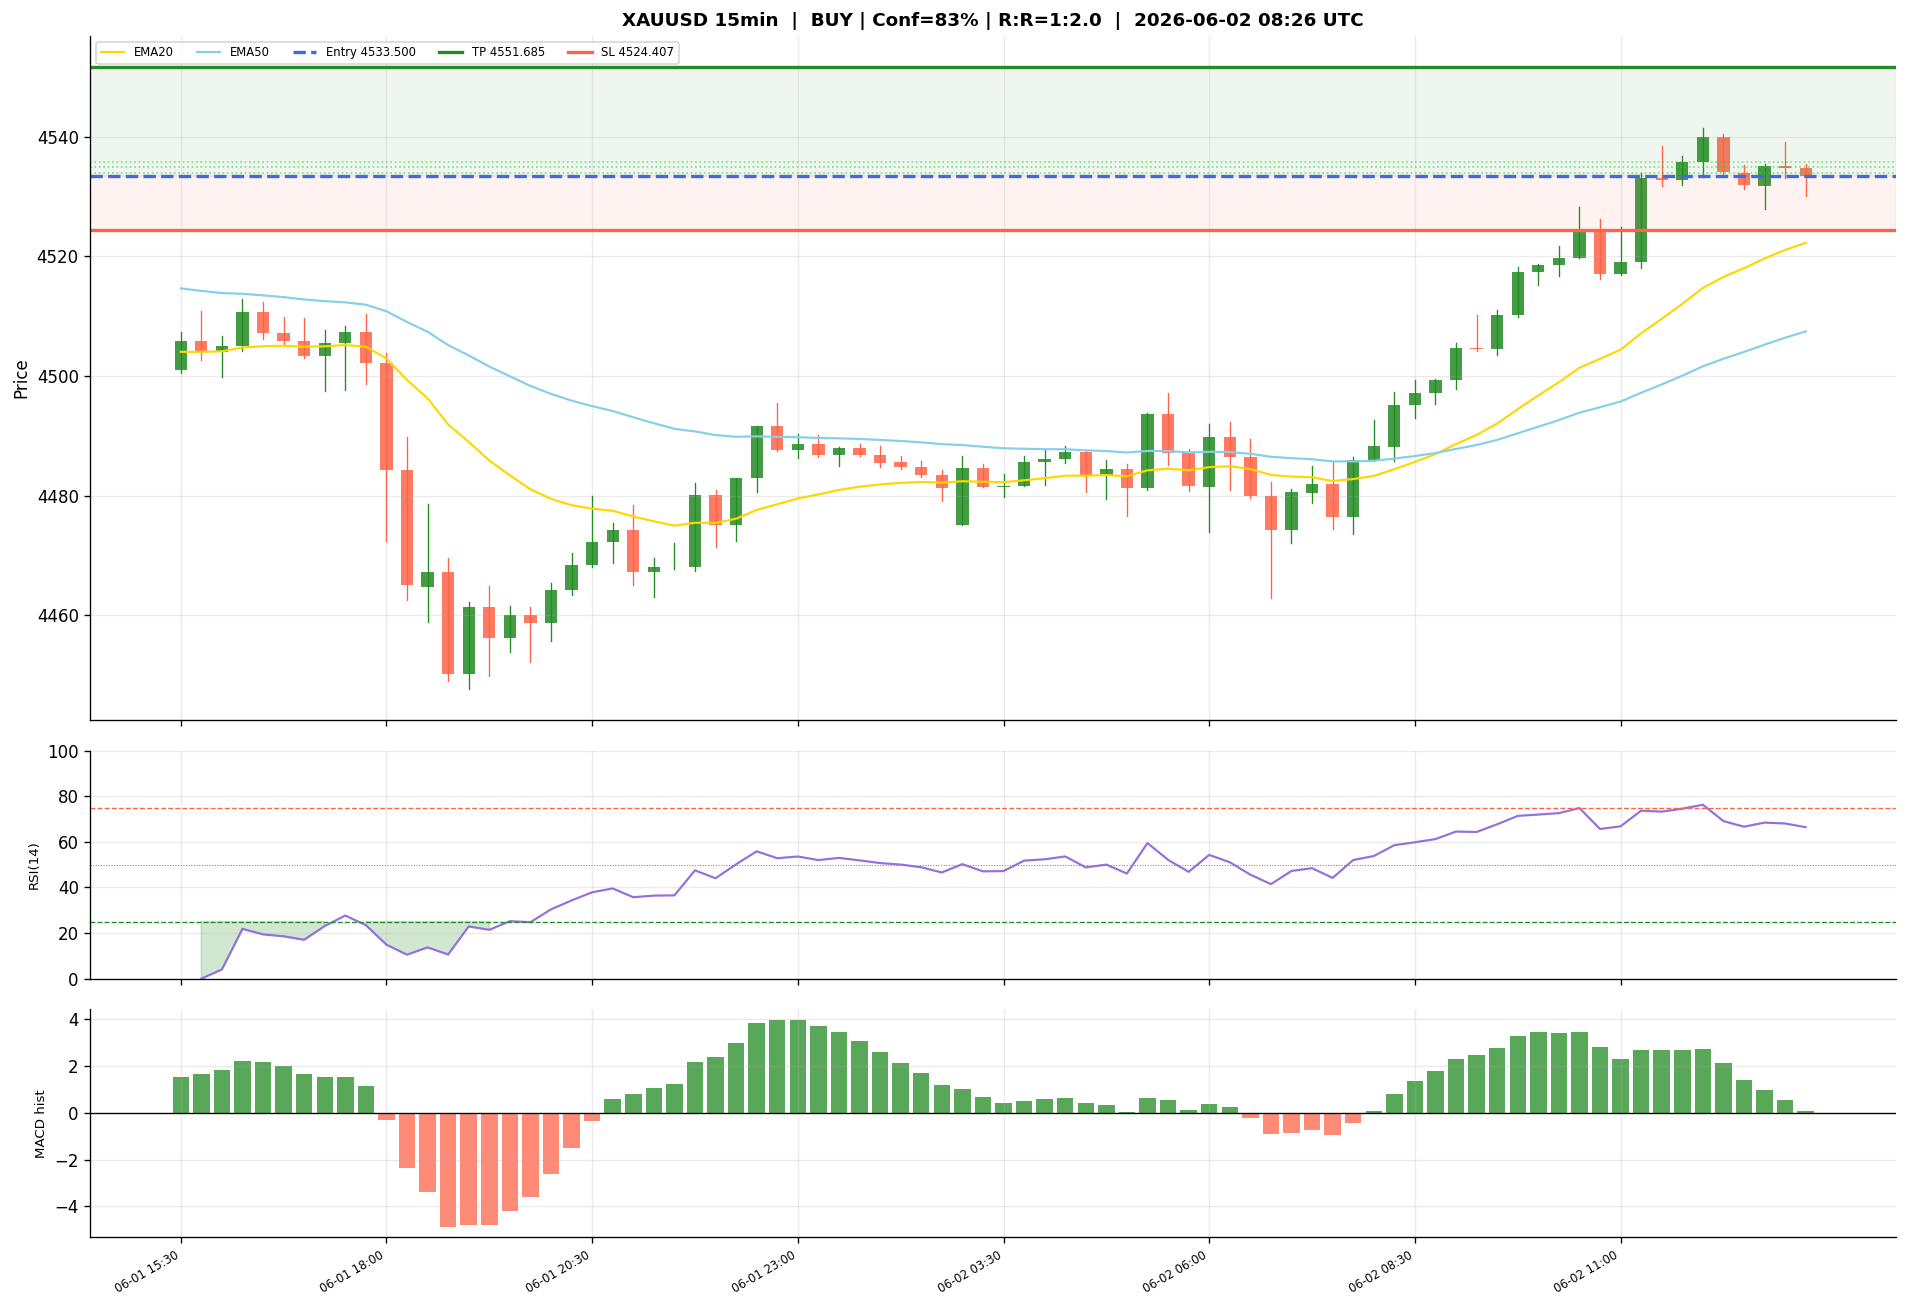

Chart saved: ../results/new_models/plots/signal_chart.png


In [224]:
# ── Chart: candlesticks + EMA + RSI + MACD + signal levels ───────────────

LOOKBACK  = 80
df_plot   = entry_df.tail(LOOKBACK).copy()
feat_plot = compute_features(entry_df).tail(LOOKBACK)
n, xs     = len(df_plot), range(len(df_plot))

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(16, 11), gridspec_kw={'height_ratios': [3, 1, 1]}, sharex=True
)

# ── Candlesticks ──────────────────────────────────────────────────────────
for i, (_, row) in enumerate(df_plot.iterrows()):
    col = 'forestgreen' if row['close'] >= row['open'] else 'tomato'
    ax1.plot([i, i], [row['low'], row['high']], color=col, lw=0.8)
    ax1.bar(i, abs(row['close'] - row['open']),
            bottom=min(row['open'], row['close']), color=col, alpha=0.85, width=0.6)

# EMAs
for col_name, color, label in [('ema_20', 'gold', 'EMA20'), ('ema_50', 'skyblue', 'EMA50')]:
    if col_name in feat_plot.columns:
        ax1.plot(xs, feat_plot[col_name].values, color=color, lw=1.3, label=label, zorder=3)

# Signal levels
if sig:
    ax1.axhline(sig['entry'], color='royalblue',   ls='--', lw=2.0, label=f'Entry {sig["entry"]:.3f}')
    ax1.axhline(sig['tp'],    color='forestgreen',  ls='-',  lw=2.0, label=f'TP {sig["tp"]:.3f}')
    ax1.axhline(sig['sl'],    color='tomato',        ls='-',  lw=2.0, label=f'SL {sig["sl"]:.3f}')
    ax1.axhspan(min(sig['entry'], sig['tp']), max(sig['entry'], sig['tp']), alpha=0.07, color='forestgreen')
    ax1.axhspan(min(sig['entry'], sig['sl']), max(sig['entry'], sig['sl']), alpha=0.07, color='tomato')
    for lp in sig.get('tp_ladder', []):
        ax1.axhline(lp, color='limegreen', ls=':', lw=1.0, alpha=0.6)

title = (f'{sig["signal"]} | Conf={sig["confidence"]}% | R:R=1:{sig["rr"]:.1f}'
         if sig else 'NO SIGNAL')
ax1.set_title(f'{ASSET} {ENTRY_TF}  |  {title}  |  '
              f'{datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")}',
              fontweight='bold', fontsize=11)
ax1.set_ylabel('Price')
ax1.legend(fontsize=7, loc='upper left', ncol=5)

# ── RSI panel ─────────────────────────────────────────────────────────────
rsi_vals = calc_rsi(df_plot['close'], 14).values
ax2.plot(xs, rsi_vals, color='mediumpurple', lw=1.3)
ax2.axhline(RSI_OVERBOUGHT, color='tomato',      ls='--', lw=0.8)
ax2.axhline(RSI_OVERSOLD,   color='forestgreen', ls='--', lw=0.8)
ax2.axhline(50,             color='gray',        ls=':',  lw=0.6)
ax2.fill_between(xs, rsi_vals, RSI_OVERBOUGHT, where=(rsi_vals > RSI_OVERBOUGHT), alpha=0.2, color='tomato')
ax2.fill_between(xs, rsi_vals, RSI_OVERSOLD,   where=(rsi_vals < RSI_OVERSOLD),   alpha=0.2, color='forestgreen')
ax2.set_ylim(0, 100)
ax2.set_ylabel('RSI(14)', fontsize=8)

# ── MACD histogram panel ───────────────────────────────────────────────────
if 'macd_hist' in feat_plot.columns:
    mh = feat_plot['macd_hist'].values
    ax3.bar(xs, mh, color=['forestgreen' if v >= 0 else 'tomato' for v in mh], alpha=0.75)
    ax3.axhline(0, color='black', lw=0.8)
ax3.set_ylabel('MACD hist', fontsize=8)

# X labels
ticks = list(range(0, n, max(1, n // 8)))
ax3.set_xticks(ticks)
ax3.set_xticklabels(
    [df_plot.index[t].strftime('%m-%d %H:%M') for t in ticks],
    rotation=30, ha='right', fontsize=7
)

plt.tight_layout()
out_path = '../results/new_models/plots/signal_chart.png'
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f'Chart saved: {out_path}')

In [ ]:
LIVE             = True
SCAN_INTERVAL_S  = 300   # 5 min default (no open trade)
SCAN_WITH_TRADE  = 2700  # 30 min when trade open

import threading
import time

try:
    live_stop.set()
    time.sleep(3)
except:
    pass

live_stop = threading.Event()

def calculate_ladder(entry, direction, atr,
                     sl2_mult=1.5, rr_ratio=2.0):
    TIGHT_SL_PIPS = 60
    QUICK_TP_PIPS = 100
    sl2_dist = atr * sl2_mult
    tp2_dist = sl2_dist * rr_ratio

    if direction == 'BUY':
        sl1 = entry - TIGHT_SL_PIPS * 0.1
        sl2 = entry - sl2_dist
        tp1 = entry + QUICK_TP_PIPS * 0.1
        tp2 = entry + tp2_dist
    else:
        sl1 = entry + TIGHT_SL_PIPS * 0.1
        sl2 = entry + sl2_dist
        tp1 = entry - QUICK_TP_PIPS * 0.1
        tp2 = entry - tp2_dist

    return {
        'sl1': round(sl1, 3),
        'sl2': round(sl2, 3),
        'tp1': round(tp1, 3),
        'tp2': round(tp2, 3),
        'pips_sl1': TIGHT_SL_PIPS,
        'pips_sl2': round(sl2_dist * 10, 0),
        'pips_tp1': QUICK_TP_PIPS,
        'pips_tp2': round(tp2_dist * 10, 0),
    }

_scanner_running = False
def _live_worker():
    global _scanner_running

    if _scanner_running:
        print("Already running — skipping")
        return

    _scanner_running  = True
    _count            = 0
    _last             = None
    _last_signal_time = None
    _last_signal_dir  = None
    _trade_open       = False  # Track if trade is open
    SIGNAL_COOLDOWN   = 2700  # 45 min cooldown after signal (reduce noise)

    print("Scanner started — single instance")
    print(f"No trade: scan every {SCAN_INTERVAL_S}s")
    print(f"Trade open: scan every {SCAN_WITH_TRADE}s")

    while not live_stop.is_set():
        _count += 1
        now = datetime.now(timezone.utc).strftime(
            '%H:%M:%S UTC'
        )

        # Dynamic interval
        current_interval = (
            SCAN_WITH_TRADE if _trade_open
            else SCAN_INTERVAL_S
        )

        try:
            fresh   = fetch_multi_timeframe(
                ASSET, TIMEFRAMES, bars=500
            )
            f_entry = fresh[ENTRY_TF]
            f_price = float(f_entry['close'].iloc[-1])
            f_atr   = float(calc_atr(f_entry, 14).iloc[-1])
            f_fc    = run_ensemble_forecast(
                f_entry, ENTRY_TF, TRAIN_BARS,
                FORECAST_H, use_chronos=USE_CHRONOS
            )
            bar_id  = str(f_entry.index[-1])
            dir_lbl = (
                'BUY'  if f_fc['direction'] > 0 else
                'SELL' if f_fc['direction'] < 0 else
                'FLAT'
            )

            if dir_lbl != 'FLAT' and bar_id != _last:
                _last = bar_id

                f_feat  = compute_features(f_entry)
                f_adx   = float(
                    f_feat['adx_14'].iloc[-1]
                ) if 'adx_14' in f_feat.columns else 0
                f_rsi   = float(
                    f_feat['rsi_14'].iloc[-1]
                ) if 'rsi_14' in f_feat.columns else 50
                f_macd  = float(
                    f_feat['macd_hist'].iloc[-1]
                ) if 'macd_hist' in f_feat.columns else 0
                f_ema20 = float(
                    f_feat['ema_20'].iloc[-1]
                ) if 'ema_20' in f_feat.columns else f_price

                # Filter 1: ADX
                if f_adx < ADX_TREND_THRESHOLD:
                    print(f'[{now}][{_count:4d}] '
                          f'SKIP — ADX={f_adx:.1f}')
                    continue

                # Filter 2: RSI
                if dir_lbl == 'BUY' and \
                        f_rsi > RSI_OVERBOUGHT:
                    print(f'[{now}][{_count:4d}] '
                          f'SKIP BUY — RSI={f_rsi:.0f}')
                    continue
                if dir_lbl == 'SELL' and \
                        f_rsi < RSI_OVERSOLD:
                    print(f'[{now}][{_count:4d}] '
                          f'SKIP SELL — RSI={f_rsi:.0f}')
                    continue

                # Filter 3: Cooldown
                if (
                    _last_signal_time and
                    dir_lbl == _last_signal_dir
                ):
                    elapsed = (
                        datetime.now(timezone.utc) -
                        _last_signal_time
                    ).seconds
                    if elapsed < SIGNAL_COOLDOWN:
                        print(f'[{now}][{_count:4d}] '
                              f'SKIP — cooldown {elapsed}s')
                        continue

                # Filter 4: Multi-TF
                f_snaps  = build_multi_tf_snapshot(fresh)
                f_scores = {
                    tf: _score_timeframe(snap)
                    for tf, snap in f_snaps.items()
                }
                aligned = [
                    tf for tf, sc in f_scores.items()
                    if sc['direction'] == (
                        1 if dir_lbl == 'BUY' else -1
                    )
                ]
                opposite = [
                    tf for tf, sc in f_scores.items()
                    if sc['direction'] == (
                        -1 if dir_lbl == 'BUY' else 1
                    )
                ]
                total_tfs = len(f_scores)
                align_pct = (
                    len(aligned) / total_tfs * 100
                    if total_tfs > 0 else 0
                )
                if len(aligned) < 2:
                    print(f'[{now}][{_count:4d}] '
                          f'SKIP — {len(aligned)}/{total_tfs} '
                          f'TFs (need 2+)')
                    continue
                # Filter 5: Confidence
                conf  = 0
                conf += min(35, int(align_pct * 0.5))
                conf += 20 if f_adx >= ADX_TREND_THRESHOLD \
                           else 5
                conf += 15 if abs(
                    f_fc['pred_return']
                ) > 0.0003 else 8
                conf += 15 if (
                    (f_macd > 0) == (dir_lbl == 'BUY')
                ) else 0
                conf += 10 if (
                    (f_price > f_ema20) ==
                    (dir_lbl == 'BUY')
                ) else 0
                conf += 5 if len(opposite) == 0 else 0
                conf  = min(conf, 95)

                if conf < CONFIDENCE_THRESHOLD:
                    print(f'[{now}][{_count:4d}] '
                          f'SKIP — conf={conf}%')
                    continue

                # TP probability
                tp_prob = (
                    70 if f_adx >= 40 else
                    58 if f_adx >= 30 else 48
                )
                if abs(f_fc['pred_return']) >= 0.0003:
                    tp_prob += 10
                elif abs(f_fc['pred_return']) >= 0.0002:
                    tp_prob += 5
                tp_prob = min(tp_prob, 85)
                sl_prob = 100 - tp_prob

                # Entry + Ladder
                e      = float(f_entry['close'].iloc[-1])
                ladder = calculate_ladder(e, dir_lbl, f_atr)

                # ── News + Sentiment ──────────────────
                in_nz, nz_event = is_news_zone()
                news_warning = (
                    f'⚠️ NEWS: {nz_event["title"]} '
                    f'in {nz_event["minutes"]:.0f} min'
                    if in_nz else '📰 News: Clear'
                )
                sentiment_warning = get_sentiment_bias(
                    dir_lbl
                )
                # ─────────────────────────────────────

                _last_signal_time = datetime.now(timezone.utc)
                _last_signal_dir  = dir_lbl
                _trade_open       = True  # Mark trade open
                
                msg = (
                    f'📅 {datetime.now(timezone.utc).strftime("%A, %d %b %Y")} | '
                    f'🕐 {now}\n'
                    f'[{_count:4d}] '
                    f'⭐ {dir_lbl} {ASSET}\n'
                    f'Entry: {e:.3f}\n'
                    f'━━━━━━━━━━━━━━━━\n'
                    f'SL1: {ladder["sl1"]:.3f} '
                    f'(-{ladder["pips_sl1"]} pips)\n'
                    f'SL2: {ladder["sl2"]:.3f} '
                    f'(-{ladder["pips_sl2"]:.0f} pips)\n'
                    f'━━━━━━━━━━━━━━━━\n'
                    f'TP1: {ladder["tp1"]:.3f} '
                    f'(+{ladder["pips_tp1"]} pips)\n'
                    f'TP2: {ladder["tp2"]:.3f} '
                    f'(+{ladder["pips_tp2"]:.0f} pips)\n'
                    f'━━━━━━━━━━━━━━━━\n'
                    f'Conf: {conf}% | '
                    f'TP: {tp_prob}% | '
                    f'ADX: {f_adx:.1f}\n'
                    f'RSI: {f_rsi:.1f} | '
                    f'TFs: {len(aligned)}/{total_tfs}\n'
                    f'Pred: {f_fc["pred_return"]:+.4f}\n'
                    f'━━━━━━━━━━━━━━━━\n'
                    f'{news_warning}\n'
                    f'{sentiment_warning}\n'
                    f'━━━━━━━━━━━━━━━━\n'
                    f'🔬 Beta Testing — Ahmed R. Hussain'
                )
                print(msg)

                import requests
                # Replace with your Telegram token and chat_id
                TELEGRAM_TOKEN = "YOUR_TELEGRAM_TOKEN"
                CHAT_ID = "YOUR_CHAT_ID"
                requests.post(
                    f'https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendMessage',
                    data={'chat_id': CHAT_ID, 'text': msg}
                )

                try:
                    from src.signal_logger import SignalLogger
                    logger = SignalLogger()
                    logger.log_signal(
                        asset=ASSET,
                        timeframe=ENTRY_TF,
                        signal=dir_lbl,
                        entry=e,
                        stop_loss=ladder['sl2'],
                        take_profit=ladder['tp2'],
                        pred=f_fc['pred_return'],
                        adx=f_adx,
                        confidence=conf,
                        tp_prob=tp_prob,
                        timestamp=now,
                        ladder=ladder
                    )
                except Exception as log_err:
                    print(f'Log error: {log_err}')

            else:
                if _count % 3 == 0:
                    trade_status = (
                        "TRADE OPEN (30min)"
                        if _trade_open else
                        "No trade (5min)"
                    )
                    print(
                        f'[{now}][{_count:4d}] '
                        f'{dir_lbl:4s} | '
                        f'{f_price:.3f} | '
                        f'{trade_status}'
                    )

            # Bottom of loop — SAME line for both branches:
        except Exception as exc:
            print(f'[{now}] Error: {exc}')

        live_stop.wait(current_interval)

    _scanner_running = False
    print('Scanner stopped.')

# ── Start ─────────────────────────────────────────────────
if LIVE:
    live_stop.clear()
    t = threading.Thread(
        target=_live_worker,
        name='scanner',
        daemon=True
    )
    t.start()
    print(f'Live scanner ON: {ASSET} {ENTRY_TF}')
    print(f'No trade:    scan every 5 min')
    print(f'Trade open:  scan every 30 min')
    print('Set LIVE=False and re-run to stop.')
else:
    live_stop.set()
    print('Scanner OFF.')

Scanner stopped.
Scanner started — single instanceLive scanner ON: XAUUSD 15min
No trade:    scan every 5 min
Trade open:  scan every 30 min
Set LIVE=False and re-run to stop.

No trade: scan every 300s
Trade open: scan every 2700s


In [226]:
LIVE             = True
SCAN_INTERVAL_S  = 300
SCAN_WITH_TRADE  = 2700

import threading
import time
import requests

try:
    live_stop.set()
    time.sleep(3)
except:
    pass

live_stop = threading.Event()

# ── Telegram Config ───────────────────────────────────────────
TELEGRAM_TOKEN   = "8829353259:AAFzIJCLjZQNJuJfE6sPL_KH6fpar6evxeQ"
# ── User packages ─────────────────────────────────────────────
# chat_id: daily signal limit (999 = unlimited)
USERS = {
    '8300273044': 10,   # You —10-limited
    # Add brother's ID here:
    # 'other_CHAT_ID': 999,   # Brother — paid
    # 'FREE_USER_ID':    3,     # Free tier
}

# ── Per-user signal counter ───────────────────────────────────
_user_signals = {}  # {chat_id: {'date': date, 'count': int}}

def check_and_send(msg, limit_reached=False):
    """
    Send signal OR limit message to each user
    based on their daily allowance
    """
    today = datetime.now(timezone.utc).date()

    for chat_id, limit in USERS.items():

        # Init user counter
        if chat_id not in _user_signals:
            _user_signals[chat_id] = {
                'date':  today,
                'count': 0
            }

        user = _user_signals[chat_id]

        # Reset if new day
        if user['date'] != today:
            user['date']  = today
            user['count'] = 0

        if user['count'] < limit:
            # Send signal
            requests.post(
                f'https://api.telegram.org/'
                f'bot{TELEGRAM_TOKEN}/sendMessage',
                data={'chat_id': chat_id, 'text': msg},
                timeout=10
            )
            user['count'] += 1
            print(f'  → Sent to {chat_id} '
                  f'({user["count"]}/{limit})')

        else:
            # Send limit message
            limit_msg = (
                f'🔒 Daily limit reached '
                f'({limit}/{limit} signals used)\n'
                f'━━━━━━━━━━━━━━━━\n'
                f'You have used all {limit} signals '
                f'for today.\n\n'
                f'Upgrade your package to receive '
                f'more signals:\n\n'
                f'• Standard — 10 signals/day\n'
                f'• Premium  — Unlimited signals\n'
                f'━━━━━━━━━━━━━━━━\n'
                f'📩 Contact: @ahmedrh_signals\n'
                f'🔬 Beta Testing — Ahmed R. Hussain'
            )
            requests.post(
                f'https://api.telegram.org/'
                f'bot{TELEGRAM_TOKEN}/sendMessage',
                data={
                    'chat_id': chat_id,
                    'text':    limit_msg
                },
                timeout=10
            )
            print(f'  → Limit reached for {chat_id}')


# ── Ladder ────────────────────────────────────────────────────
def calculate_ladder(entry, direction, atr,
                     sl2_mult=1.5, rr_ratio=2.0):
    TIGHT_SL_PIPS = 50
    QUICK_TP_PIPS = 100
    sl2_dist = atr * sl2_mult
    tp2_dist = sl2_dist * rr_ratio

    if direction == 'BUY':
        sl1 = entry - TIGHT_SL_PIPS * 0.1
        sl2 = entry - sl2_dist
        tp1 = entry + QUICK_TP_PIPS * 0.1
        tp2 = entry + tp2_dist
    else:
        sl1 = entry + TIGHT_SL_PIPS * 0.1
        sl2 = entry + sl2_dist
        tp1 = entry - QUICK_TP_PIPS * 0.1
        tp2 = entry - tp2_dist

    return {
        'sl1':      round(sl1, 3),
        'sl2':      round(sl2, 3),
        'tp1':      round(tp1, 3),
        'tp2':      round(tp2, 3),
        'pips_sl1': TIGHT_SL_PIPS,
        'pips_sl2': round(sl2_dist * 10, 0),
        'pips_tp1': QUICK_TP_PIPS,
        'pips_tp2': round(tp2_dist * 10, 0),
    }


# ── News functions ────────────────────────────────────────────
def get_news_events():
    try:
        url = (
            "https://nfs.faireconomy.media/"
            "ff_calendar_thisweek.json"
        )
        r      = requests.get(url, timeout=10)
        events = r.json()
        now    = datetime.now(timezone.utc)
        upcoming = []
        for event in events:
            if event.get('impact') != 'High':
                continue
            try:
                et = datetime.fromisoformat(
                    event['date'].replace('Z', '+00:00')
                )
                diff = (et - now).total_seconds() / 60
                if -30 <= diff <= 60:
                    upcoming.append({
                        'title':   event.get('title', ''),
                        'country': event.get('country', ''),
                        'minutes': diff
                    })
            except:
                continue
        return upcoming
    except:
        return []


def is_news_zone():
    events   = get_news_events()
    relevant = ['USD', 'XAU', 'US']
    for event in events:
        if event['country'] in relevant:
            return True, event
    return False, None


def get_fear_greed():
    try:
        url = (
            "https://production.dataviz.cnn.io/"
            "index/fearandgreed/graphdata"
        )
        headers = {'User-Agent': 'Mozilla/5.0'}
        r       = requests.get(
            url, headers=headers, timeout=10
        )
        data   = r.json()
        score  = float(
            data['fear_and_greed']['score']
        )
        rating = data['fear_and_greed']['rating']
        return score, rating
    except:
        return 50, 'neutral'


def get_sentiment_bias(direction):
    score, rating = get_fear_greed()
    if direction == 'BUY':
        if score < 40:
            return f'😨 Fear ({score:.0f}) confirms BUY'
        elif score > 60:
            return f'😎 Greed ({score:.0f}) — caution BUY'
        else:
            return f'😐 Neutral ({score:.0f})'
    else:
        if score > 60:
            return f'😎 Greed ({score:.0f}) confirms SELL'
        elif score < 40:
            return f'😨 Fear ({score:.0f}) — caution SELL'
        else:
            return f'😐 Neutral ({score:.0f})'


# ── Scanner ───────────────────────────────────────────────────
_scanner_running = False

def _live_worker():
    global _scanner_running

    if _scanner_running:
        print("Already running — skipping")
        return

    _scanner_running  = True
    _count            = 0
    _last             = None
    _last_signal_time = None
    _last_signal_dir  = None
    _trade_open       = False
    _trade_open_time  = None
    SIGNAL_COOLDOWN   = 2700
    TRADE_TIMEOUT     = 14400

    print("Scanner started — single instance")
    print(f"No trade:    every {SCAN_INTERVAL_S}s")
    print(f"Trade open:  every {SCAN_WITH_TRADE}s")
    print(f"Users: {len(USERS)} configured")

    while not live_stop.is_set():
        _count += 1
        now = datetime.now(timezone.utc).strftime(
            '%H:%M:%S UTC'
        )

        # Auto-reset trade after 4 hours
        if _trade_open and _trade_open_time:
            age = (
                datetime.now(timezone.utc) -
                _trade_open_time
            ).seconds
            if age > TRADE_TIMEOUT:
                _trade_open      = False
                _trade_open_time = None
                print(f'[{now}] Trade auto-reset')

        current_interval = (
            SCAN_WITH_TRADE if _trade_open
            else SCAN_INTERVAL_S
        )

        try:
            fresh   = fetch_multi_timeframe(
                ASSET, TIMEFRAMES, bars=500
            )
            f_entry = fresh[ENTRY_TF]
            f_price = float(f_entry['close'].iloc[-1])
            f_atr   = float(
                calc_atr(f_entry, 14).iloc[-1]
            )
            f_fc    = run_ensemble_forecast(
                f_entry, ENTRY_TF, TRAIN_BARS,
                FORECAST_H, use_chronos=USE_CHRONOS
            )
            bar_id  = str(f_entry.index[-1])
            dir_lbl = (
                'BUY'  if f_fc['direction'] > 0 else
                'SELL' if f_fc['direction'] < 0 else
                'FLAT'
            )

            if dir_lbl != 'FLAT' and bar_id != _last:
                _last = bar_id

                f_feat  = compute_features(f_entry)
                f_adx   = float(
                    f_feat['adx_14'].iloc[-1]
                ) if 'adx_14' in f_feat.columns else 0
                f_rsi   = float(
                    f_feat['rsi_14'].iloc[-1]
                ) if 'rsi_14' in f_feat.columns else 50
                f_macd  = float(
                    f_feat['macd_hist'].iloc[-1]
                ) if 'macd_hist' in f_feat.columns else 0
                f_ema20 = float(
                    f_feat['ema_20'].iloc[-1]
                ) if 'ema_20' in f_feat.columns \
                  else f_price

                # Filter 1: ADX
                if f_adx < ADX_TREND_THRESHOLD:
                    print(f'[{now}][{_count:4d}] '
                          f'SKIP — ADX={f_adx:.1f}')
                    continue

                # Filter 2: RSI
                if dir_lbl == 'BUY' and \
                        f_rsi > RSI_OVERBOUGHT:
                    print(f'[{now}][{_count:4d}] '
                          f'SKIP BUY — RSI={f_rsi:.0f}')
                    continue
                if dir_lbl == 'SELL' and \
                        f_rsi < RSI_OVERSOLD:
                    print(f'[{now}][{_count:4d}] '
                          f'SKIP SELL — RSI={f_rsi:.0f}')
                    continue

                # Filter 3: Cooldown
                if (
                    _last_signal_time and
                    dir_lbl == _last_signal_dir
                ):
                    elapsed = (
                        datetime.now(timezone.utc) -
                        _last_signal_time
                    ).seconds
                    if elapsed < SIGNAL_COOLDOWN:
                        print(f'[{now}][{_count:4d}] '
                              f'SKIP — cooldown {elapsed}s')
                        continue

                # Filter 4: Multi-TF
                f_snaps  = build_multi_tf_snapshot(fresh)
                f_scores = {
                    tf: _score_timeframe(snap)
                    for tf, snap in f_snaps.items()
                }
                aligned = [
                    tf for tf, sc in f_scores.items()
                    if sc['direction'] == (
                        1 if dir_lbl == 'BUY' else -1
                    )
                ]
                opposite = [
                    tf for tf, sc in f_scores.items()
                    if sc['direction'] == (
                        -1 if dir_lbl == 'BUY' else 1
                    )
                ]
                total_tfs = len(f_scores)
                align_pct = (
                    len(aligned) / total_tfs * 100
                    if total_tfs > 0 else 0
                )

                if len(aligned) < 2:
                    print(f'[{now}][{_count:4d}] '
                          f'SKIP — {len(aligned)}/'
                          f'{total_tfs} TFs')
                    continue

                # Filter 5: Confidence
                conf  = 0
                conf += min(35, int(align_pct * 0.5))
                conf += (
                    20 if f_adx >= ADX_TREND_THRESHOLD
                    else 5
                )
                conf += (
                    15 if abs(
                        f_fc['pred_return']
                    ) > 0.0003 else 8
                )
                conf += (
                    15 if (f_macd > 0) ==
                    (dir_lbl == 'BUY') else 0
                )
                conf += (
                    10 if (f_price > f_ema20) ==
                    (dir_lbl == 'BUY') else 0
                )
                conf += 5 if len(opposite) == 0 else 0
                conf  = min(conf, 95)

                if conf < CONFIDENCE_THRESHOLD:
                    print(f'[{now}][{_count:4d}] '
                          f'SKIP — conf={conf}%')
                    continue

                # TP probability
                tp_prob = (
                    70 if f_adx >= 40 else
                    58 if f_adx >= 30 else 48
                )
                if abs(f_fc['pred_return']) >= 0.0003:
                    tp_prob += 10
                elif abs(f_fc['pred_return']) >= 0.0002:
                    tp_prob += 5
                tp_prob = min(tp_prob, 85)

                # Entry + Ladder
                e      = float(f_entry['close'].iloc[-1])
                ladder = calculate_ladder(e, dir_lbl, f_atr)

                # News + Sentiment
                in_nz, nz_event = is_news_zone()
                news_warning = (
                    f'⚠️ NEWS: {nz_event["title"]} '
                    f'in {nz_event["minutes"]:.0f} min'
                    if in_nz else '📰 News: Clear'
                )
                sentiment_warning = get_sentiment_bias(
                    dir_lbl
                )

                _last_signal_time = datetime.now(
                    timezone.utc
                )
                _last_signal_dir  = dir_lbl
                _trade_open       = True
                _trade_open_time  = datetime.now(
                    timezone.utc
                )

                # Message
                msg = (
                    f'📅 {datetime.now(timezone.utc).strftime("%A, %d %b %Y")} | '
                    f'🕐 {now}\n'
                    f'[{_count:4d}] '
                    f'⭐ {dir_lbl} {ASSET}\n'
                    f'Entry: {e:.3f}\n'
                    f'━━━━━━━━━━━━━━━━\n'
                    f'SL1: {ladder["sl1"]:.3f} '
                    f'(-{ladder["pips_sl1"]} pips)\n'
                    f'SL2: {ladder["sl2"]:.3f} '
                    f'(-{ladder["pips_sl2"]:.0f} pips)\n'
                    f'━━━━━━━━━━━━━━━━\n'
                    f'TP1: {ladder["tp1"]:.3f} '
                    f'(+{ladder["pips_tp1"]} pips)\n'
                    f'TP2: {ladder["tp2"]:.3f} '
                    f'(+{ladder["pips_tp2"]:.0f} pips)\n'
                    f'━━━━━━━━━━━━━━━━\n'
                    f'Conf: {conf}% | '
                    f'TP: {tp_prob}% | '
                    f'ADX: {f_adx:.1f}\n'
                    f'RSI: {f_rsi:.1f} | '
                    f'TFs: {len(aligned)}/{total_tfs}\n'
                    f'Pred: {f_fc["pred_return"]:+.4f}\n'
                    f'━━━━━━━━━━━━━━━━\n'
                    f'{news_warning}\n'
                    f'{sentiment_warning}\n'
                    f'━━━━━━━━━━━━━━━━\n'
                    f'🔬 Beta Testing — Ahmed R. Hussain'
                )

                print(msg)

                # Send to all users (with limit check)
                check_and_send(msg)

                # Log
                try:
                    from src.signal_logger import (
                        SignalLogger
                    )
                    logger = SignalLogger()
                    logger.log_signal(
                        asset=ASSET,
                        timeframe=ENTRY_TF,
                        signal=dir_lbl,
                        entry=e,
                        stop_loss=ladder['sl2'],
                        take_profit=ladder['tp2'],
                        pred=f_fc['pred_return'],
                        adx=f_adx,
                        confidence=conf,
                        tp_prob=tp_prob,
                        timestamp=now,
                        ladder=ladder
                    )
                except Exception as log_err:
                    print(f'Log error: {log_err}')

            else:
                if _count % 3 == 0:
                    status = (
                        'TRADE OPEN (45min)'
                        if _trade_open else
                        'No trade (5min)'
                    )
                    print(
                        f'[{now}][{_count:4d}] '
                        f'{dir_lbl:4s} | '
                        f'{f_price:.3f} | '
                        f'{status}'
                    )

        except Exception as exc:
            print(f'[{now}] Error: {exc}')

        live_stop.wait(current_interval)

    _scanner_running = False
    print('Scanner stopped.')


# ── Start ──────────────────────────────────────────────────────
if LIVE:
    live_stop.clear()
    t = threading.Thread(
        target=_live_worker,
        name='scanner',
        daemon=True
    )
    t.start()
    print(f'Live scanner ON: {ASSET} {ENTRY_TF}')
    print(f'No trade:    every 5 min')
    print(f'Trade open:  every 45 min')
    print('Set LIVE=False and re-run to stop.')
else:
    live_stop.set()
    print('Scanner OFF.')

Scanner started — single instanceLive scanner ON: XAUUSD 15min
No trade:    every 5 min
Trade open:  every 45 min
Set LIVE=False and re-run to stop.

No trade:    every 300s
Trade open:  every 2700s
Users: 1 configured


In [227]:
# import requests

# # Credentials
# TELEGRAM_TOKEN = "8829353259:AAFzIJCLjZQNJuJfE6sPL_KH6fpar6evxeQ"
# CHAT_ID = "8300273044"

# def send_custom_alert():
#     url = f'https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendMessage'
    
#     # Constructing the updated multi-line message
#     message_text = (
#         "⚠️ SYSTEM NOTICE: System generated 5 signals in a short time. "
#         "You have reached the limit. Please wait for 4 hours.\n\n"
#         "==================================================\n"
#         "📊 TRADING SUMMARY FOR: 6/2/2026\n"
#         "==================================================\n"
#         "📈 Total Trades Executed : 5\n"
#         "✅ Take Profit (TP) Hits : 4\n"
#         "❌ Stop Loss (SL) Hits   : 1\n"
#         "🎯 Win Rate              : 80.00%\n"
#         "🟢 Total Pips Gained     : +367.0 pips\n"
#         "==================================================\n\n"
#         "📝 INDIVIDUAL TRADE BREAKDOWN:\n"
#         "--------------------------------------------------\n"
#         "⏰ Time: 5:26 | BUY XAUUSD | Outcome: TP | Pips: +107 | (TP2 hit +107)\n"
#         "⏰ Time: 5:44 | BUY XAUUSD | Outcome: TP | Pips: +100 | (TP1 hit +100)\n"
#         "⏰ Time: 6:16 | BUY XAUUSD | Outcome: TP | Pips: +122 | (TP2 hit +122)\n"
#         "⏰ Time: 6:42 | BUY XAUUSD | Outcome: TP | Pips: +100 | (TP1 hit +100)\n"
#         "⏰ Time: 7:32 | BUY XAUUSD | Outcome: SL | Pips: -62  | (SL2 hit -62)\n"
#         "=================================================="
#     )

#     payload = {
#         'chat_id': CHAT_ID, 
#         'text': message_text
#     }
    
#     try:
#         response = requests.post(url, json=payload)
#         response.raise_for_status() 
#         print("Prank message updated and sent successfully!")
#         return response.json()
#     except requests.exceptions.RequestException as e:
#         print(f"Failed to send message: {e}")
#         return None

# # Execute the function
# send_custom_alert()

📅 Tuesday, 02 Jun 2026 | 🕐 08:27:04 UTC
[   1] ⭐ BUY XAUUSD
Entry: 4533.120
━━━━━━━━━━━━━━━━
SL1: 4527.120 (-60 pips)
SL2: 4521.754 (-114 pips)
━━━━━━━━━━━━━━━━
TP1: 4543.120 (+100 pips)
TP2: 4555.852 (+227 pips)
━━━━━━━━━━━━━━━━
Conf: 83% | TP: 58% | ADX: 32.7
RSI: 66.0 | TFs: 2/4
Pred: +0.0001
━━━━━━━━━━━━━━━━
📰 News: Clear
😐 Neutral (50)
━━━━━━━━━━━━━━━━
🔬 Beta Testing — Ahmed R. Hussain
Logged: BUY XAUUSD @ 4533.12
📅 Tuesday, 02 Jun 2026 | 🕐 08:27:08 UTC
[   1] ⭐ BUY XAUUSD
Entry: 4532.820
━━━━━━━━━━━━━━━━
SL1: 4527.820 (-50 pips)
SL2: 4521.454 (-114 pips)
━━━━━━━━━━━━━━━━
TP1: 4542.820 (+100 pips)
TP2: 4555.552 (+227 pips)
━━━━━━━━━━━━━━━━
Conf: 78% | TP: 58% | ADX: 32.7
RSI: 65.6 | TFs: 2/4
Pred: +0.0001
━━━━━━━━━━━━━━━━
📰 News: Clear
😐 Neutral (50)
━━━━━━━━━━━━━━━━
🔬 Beta Testing — Ahmed R. Hussain
  → Sent to 8300273044 (1/10)
Logged: BUY XAUUSD @ 4532.82
Prank message updated and sent successfully!


{'ok': True,
 'result': {'message_id': 21,
  'from': {'id': 8829353259,
   'is_bot': True,
   'first_name': 'Signale für XAU - ARH',
   'username': 'Cryptosignalsbyahmed_bot'},
  'chat': {'id': 8300273044,
   'first_name': 'Ahmed',
   'last_name': 'Hussain',
   'type': 'private'},
  'date': 1780388850,
  'text': '⚠️ SYSTEM NOTICE: System generated 5 signals in a short time. You have reached the limit. Please wait for 4 hours.\n\n==================================================\n📊 TRADING SUMMARY FOR: 6/2/2026\n==================================================\n📈 Total Trades Executed : 5\n✅ Take Profit (TP) Hits : 4\n❌ Stop Loss (SL) Hits   : 1\n🎯 Win Rate              : 80.00%\n🟢 Total Pips Gained     : +367.0 pips\n==================================================\n\n📝 INDIVIDUAL TRADE BREAKDOWN:\n--------------------------------------------------\n⏰ Time: 5:26 | BUY XAUUSD | Outcome: TP | Pips: +107 | (TP2 hit +107)\n⏰ Time: 5:44 | BUY XAUUSD | Outcome: TP | Pips: +100 | (TP1 hi

[08:32:09 UTC][   2] SKIP — cooldown 301s
[08:32:10 UTC][   3] BUY  | 4532.540 | TRADE OPEN (30min)
[08:32:12 UTC][   2] SKIP — cooldown 301s
[08:32:13 UTC][   3] BUY  | 4532.600 | TRADE OPEN (45min)
